In [4]:
import numpy as np  
import pandas as pd
import matplotlib.pyplot as plt


# Data read in 
manually add the dafta

In [5]:

data_forward_run = [
    ["0.02", 0, 9.7, 9.8, 9.8, 9.6, 9.5],
    ["0.005", 0, 9.8, 9.7, 9.4, 9.7, 9.8],
    ["0.001", 0, 7.6, 8.4, 7.9, 7.1, 8.9],
    ["0.02", 20, 9.8, 9.9, 9.8, 9.8, 9.8],
    ["0.005", 20, 9.9, 9.7, 10.0, 9.7, 9.9],
    ["0.001", 20, 2.9, 2.7, 2.0, 2.4, 2.4],
    ["0.02", 30, 9.6, 9.9, 9.9, 10.0, 9.8],
    ["0.005", 30, 10.0, 10.0, 10.2, 10.1, 10.1],
    ["0.001", 30, 2.1, 1.9, 1.5, 1.4, 1.5],
]
data_backward = [
    ["0.02",     0,  9.9, 9.9, 10.0, 10.0, 9.9],
    ["0.005",  0,  9.4, 9.3, 9.4,  9.2, 9.0],
    ["0.001",  0,  1.4, 1.2, 1.2,  1.3, 1.0],
    ["0.02",    20,  9.7, 9.8, 9.8, 10.0, 9.9],
    ["0.005", 20,  8.4, 8.9, 9.4,  9.1, 9.7],
    ["0.001", 20,  0.9, 0.9, 0.9,  1.7, 1.3],
    ["0.02",    30,  9.7, 9.9, 10.0, 9.7, 9.9],
    ["0.005", 30,  9.8, 9.8, 9.7,  9.6,10.0],
    ["0.001", 30,  0.9, 0.9, 0.8,  0.7, 0.5],
]

columns = ["Speed", "Start_pos_cm", "Run1", "Run2", "Run3", "Run4", "Run5"]
df_backward = pd.DataFrame(data_backward, columns=columns)

columns = ["Speed", "Start_pos_cm", "Run1", "Run2", "Run3", "Run4", "Run5"]

df_forward_run = pd.DataFrame(data_forward_run, columns=columns)
print(df_forward_run)

   Speed  Start_pos_cm  Run1  Run2  Run3  Run4  Run5
0   0.02             0   9.7   9.8   9.8   9.6   9.5
1  0.005             0   9.8   9.7   9.4   9.7   9.8
2  0.001             0   7.6   8.4   7.9   7.1   8.9
3   0.02            20   9.8   9.9   9.8   9.8   9.8
4  0.005            20   9.9   9.7  10.0   9.7   9.9
5  0.001            20   2.9   2.7   2.0   2.4   2.4
6   0.02            30   9.6   9.9   9.9  10.0   9.8
7  0.005            30  10.0  10.0  10.2  10.1  10.1
8  0.001            30   2.1   1.9   1.5   1.4   1.5


In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Original DataFrame (df) assumed from your earlier step

df_long = df_forward_run.melt(
    id_vars=["Speed", "Start_pos_cm"],
    value_vars=["Run1", "Run2", "Run3", "Run4", "Run5"],
    var_name="Run",
    value_name="Measurement"
)

df_long_backward = df_backward.melt(
    id_vars=["Speed", "Start_pos_cm"],
    value_vars=["Run1", "Run2", "Run3", "Run4", "Run5"],
    var_name="Run",
    value_name="Measurement"
)

# plot code
Below we will plot the data

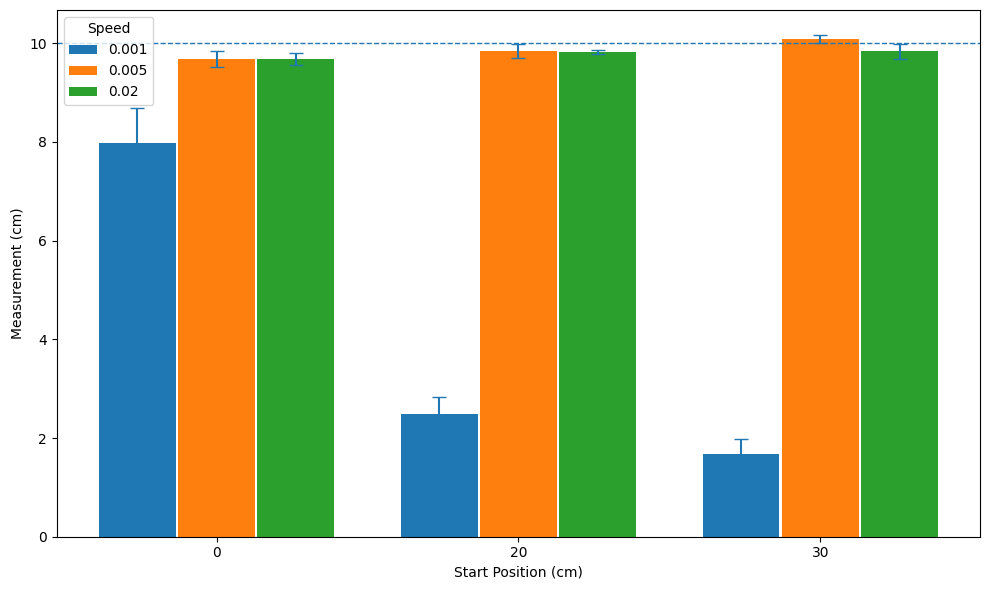

In [7]:


df_long["Speed_num"] = df_long["Speed"].str.replace("cm", "").astype(float)
speed_order = (
    df_long[["Speed", "Speed_num"]]
    .drop_duplicates()
    .sort_values("Speed_num")["Speed"]
    .tolist()
)

start_positions = sorted(df_long["Start_pos_cm"].unique())

agg = (
    df_long
    .groupby(["Start_pos_cm", "Speed"])["Measurement"]
    .agg(["mean", "std"])
    .reset_index()
)


bar_width = 0.6
intra_bar_gap = 0.02
group_spacing = 0.5

n_groups = len(start_positions)
n_speeds = len(speed_order)

group_centers = np.arange(n_groups) * (
    n_speeds * (bar_width + intra_bar_gap) + group_spacing
)

plt.figure(figsize=(10, 6))


for i, speed in enumerate(speed_order):
    xs, means, stds = [], [], []

    for g, start in enumerate(start_positions):
        row = agg[
            (agg["Start_pos_cm"] == start) &
            (agg["Speed"] == speed)
        ]

        mean = row["mean"].values[0]
        std = row["std"].values[0]

        x = group_centers[g] + (i - (n_speeds - 1) / 2) * (bar_width + intra_bar_gap)

        xs.append(x)
        means.append(mean)
        stds.append(std)

    plt.bar(xs, means, width=bar_width, label=speed)
    plt.errorbar(xs, means, yerr=stds, fmt="none", capsize=5)

# -----------------------------
# Formatting
# -----------------------------
plt.xticks(group_centers, [str(int(s)) for s in start_positions])
plt.xlabel("Start Position (cm)")
plt.ylabel("Measurement (cm)")
plt.axhline(10, linestyle="--", linewidth=1)
plt.legend(title="Speed")
plt.tight_layout()
plt.show()


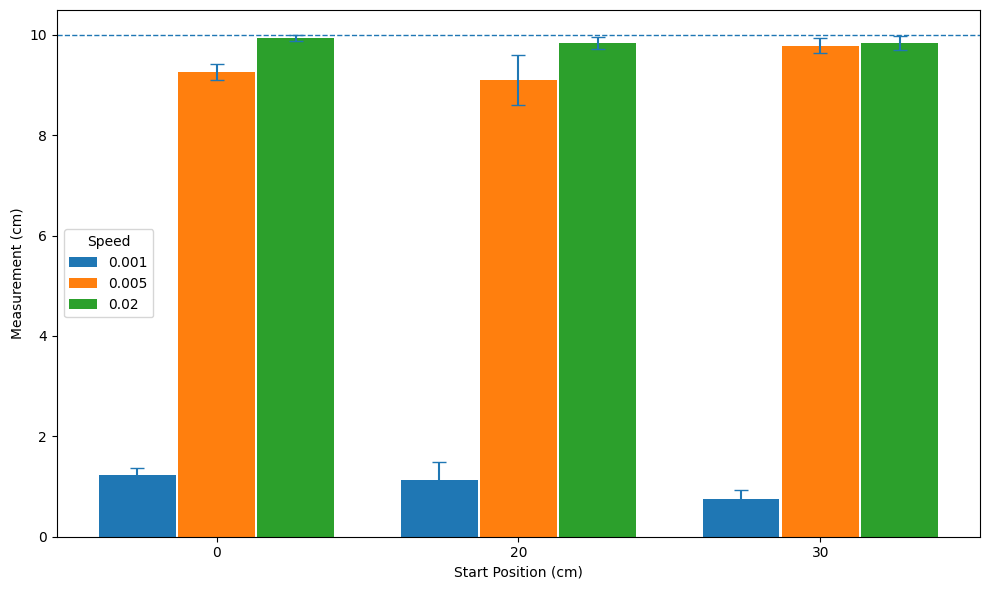

In [8]:
df_long_backward["Speed_num"] = df_long_backward["Speed"].str.replace("cm", "").astype(float)
speed_order = (
    df_long_backward[["Speed", "Speed_num"]]
    .drop_duplicates()
    .sort_values("Speed_num")["Speed"]
    .tolist()
)

start_positions = sorted(df_long_backward["Start_pos_cm"].unique())

agg = (
    df_long_backward
    .groupby(["Start_pos_cm", "Speed"])["Measurement"]
    .agg(["mean", "std"])
    .reset_index()
)


bar_width = 0.6
intra_bar_gap = 0.02
group_spacing = 0.5

n_groups = len(start_positions)
n_speeds = len(speed_order)

group_centers = np.arange(n_groups) * (
    n_speeds * (bar_width + intra_bar_gap) + group_spacing
)

plt.figure(figsize=(10, 6))


for i, speed in enumerate(speed_order):
    xs, means, stds = [], [], []

    for g, start in enumerate(start_positions):
        row = agg[
            (agg["Start_pos_cm"] == start) &
            (agg["Speed"] == speed)
        ]

        mean = row["mean"].values[0]
        std = row["std"].values[0]

        x = group_centers[g] + (i - (n_speeds - 1) / 2) * (bar_width + intra_bar_gap)

        xs.append(x)
        means.append(mean)
        stds.append(std)

    plt.bar(xs, means, width=bar_width, label=speed)
    plt.errorbar(xs, means, yerr=stds, fmt="none", capsize=5)

# -----------------------------
# Formatting
# -----------------------------
plt.xticks(group_centers, [str(int(s)) for s in start_positions])
plt.xlabel("Start Position (cm)")
plt.ylabel("Measurement (cm)")
plt.axhline(10, linestyle="--", linewidth=1)
plt.legend(title="Speed")
plt.tight_layout()
plt.show()


In [9]:
import pandas as pd

# Original data
data = {
    "Start": [8.3, 8.3, 8.2, 8.2, 8.0, 8.1, 8.0, 7.9, 7.8, 7.7],
    "Up":    [18.2, 18.2, 18.2, 18.1, 18.0, 17.9, 17.9, 17.8, 17.8, 17.6],
    "Down":  [8.3, 8.2, 8.2, 8.0, 8.1, 8.0, 7.9, 7.8, 7.7, 7.6]
}

# Create DataFrame
df1 = pd.DataFrame(data)
df1["released_up"] = [8.7, 8.7, 8.6, 8.5, 8.7, 8.7, 8.5, 8.7, 8.6, 8.7]
# Calculate distances
df1["Start_to_Up"] = df1["Up"] - df1["Start"]
df1["Up_to_Down"] = df1["Up"] - df1["Down"]

print(df1)
df1["Trial"] = np.arange(len(df1))

   Start    Up  Down  released_up  Start_to_Up  Up_to_Down
0    8.3  18.2   8.3          8.7          9.9         9.9
1    8.3  18.2   8.2          8.7          9.9        10.0
2    8.2  18.2   8.2          8.6         10.0        10.0
3    8.2  18.1   8.0          8.5          9.9        10.1
4    8.0  18.0   8.1          8.7         10.0         9.9
5    8.1  17.9   8.0          8.7          9.8         9.9
6    8.0  17.9   7.9          8.5          9.9        10.0
7    7.9  17.8   7.8          8.7          9.9        10.0
8    7.8  17.8   7.7          8.6         10.0        10.1
9    7.7  17.6   7.6          8.7          9.9        10.0


/var/folders/n1/vr1f_0y52hj2hxn2mg_d76f80000gn/T/ipykernel_64213/1864942604.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


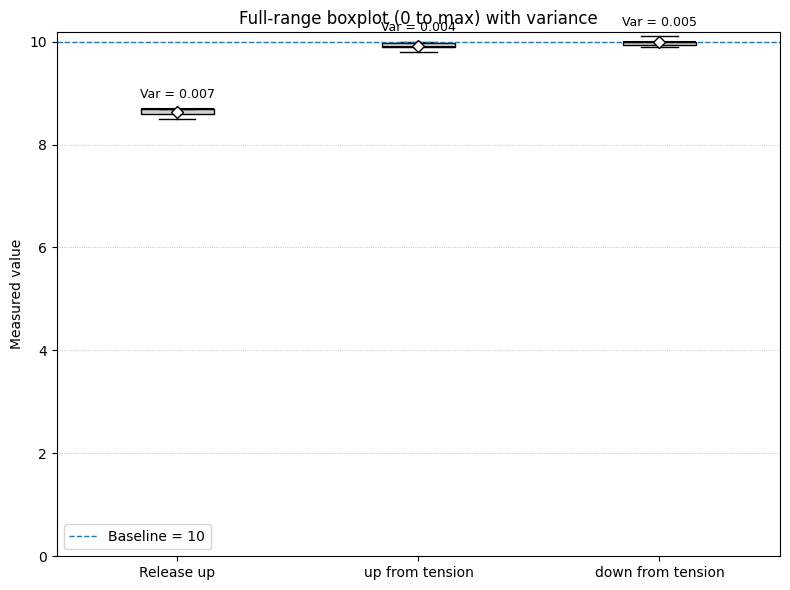

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# --- SAMPLE DATAFRAME (remove if df1 already exists) ---
data = {
    "released_up": [8.7, 8.7, 8.6, 8.5, 8.7, 8.7, 8.5, 8.7, 8.6, 8.7],
    "Start_to_Up": [9.9, 9.9, 10.0, 9.9, 10.0, 9.8, 9.9, 9.9, 10.0, 9.9],
    "Up_to_Down":  [9.9, 10.0, 10.0, 10.1, 9.9, 9.9, 10.0, 10.0, 10.1, 10.0]
}
df1 = pd.DataFrame(data)
# -----------------------------------------------------

cols = ["released_up", "Start_to_Up", "Up_to_Down"]
labels = ["Release up", "up from tension", "down from tension"]

plot_data = [df1[c].values for c in cols]

fig, ax = plt.subplots(figsize=(8, 6))

# Boxplot with whiskers spanning full range (min to max)
box = ax.boxplot(
    plot_data,
    labels=labels,
    patch_artist=True,
    showmeans=True,
    whis=(0, 100)   # FULL range (acts like bars from bottom to top)
)

# Styling
for patch in box['boxes']:
    patch.set(facecolor='lightgrey', edgecolor='black', linewidth=1)

for median in box['medians']:
    median.set(color='black', linewidth=1.5)

for mean in box['means']:
    mean.set(marker='D', markeredgecolor='black', markerfacecolor='white')

# Baseline at 10
ax.axhline(10, linestyle='--', linewidth=1, label='Baseline = 10')

# Force bars to start from zero
ax.set_ylim(bottom=0)

# Variance annotation
variances = [df1[c].var(ddof=1) for c in cols]
for i, var in enumerate(variances, start=1):
    ymax = max(plot_data[i-1])
    ax.text(i, ymax + 0.2, f'Var = {var:.3f}', ha='center', fontsize=9)

ax.set_ylabel("Measured value")
ax.set_title("Full-range boxplot (0 to max) with variance")
ax.grid(axis='y', linestyle=':', linewidth=0.6)
ax.legend()

plt.tight_layout()
plt.show()
